# **AI Dynamic Ride Pricing System**

# **1.Problem Statement**
Ride-sharing platforms dynamically adjust ride prices based on demand and supply conditions. During peak hours, high demand and limited driver availability cause prices to increase (surge pricing).

## **2.The goal of this project :**

The goal of this project is to build an AI-powered dynamic pricing model that predicts the estimated ride price using factors such as:

*number of riders requesting rides

*number of available drivers

*ride duration

*vehicle type

*location category

*List item



# **3.Project Objectives**

•	Analyse ride demand and supply patterns.

•	Build a machine learning model to predict ride prices.

•	Understand how different factors influence ride pricing.

•	Develop an interactive GUI to predict ride price.

•	Demonstrate an end-to-end AI/ML pipeline


# **Step 1 — Import Libraries**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error

import joblib

# **Step 2 — Load Dataset**

In [3]:
df = pd.read_csv("dynamic_pricing.csv")

df.head()

,Number_of_Riders,Number_of_Drivers,Location_Category,Customer_Loyalty_Status,Number_of_Past_Rides,Average_Ratings,Time_of_Booking,Vehicle_Type,Expected_Ride_Duration,Historical_Cost_of_Ride
0,90,45,Urban,Silver,13,4.47,Night,Premium,90,284.257273
1,58,39,Suburban,Silver,72,4.06,Evening,Economy,43,173.874753
2,42,31,Rural,Silver,0,3.99,Afternoon,Premium,76,329.795469
3,89,28,Rural,Regular,67,4.31,Afternoon,Premium,134,470.201232
4,78,22,Rural,Regular,74,3.77,Afternoon,Economy,149,579.681422


# **Step 3 — Data Exploration**

<Axes: xlabel='Vehicle_Type'>

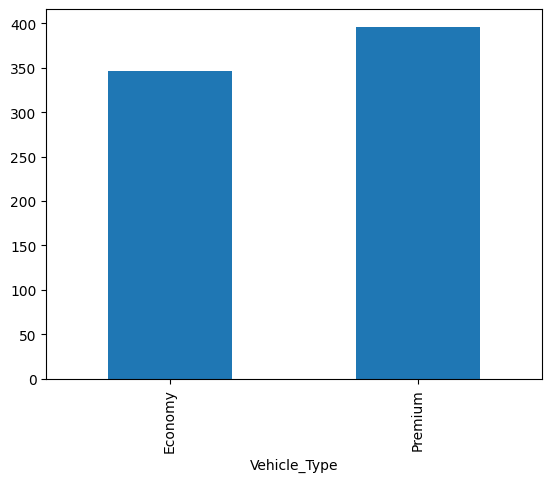

In [4]:
df.groupby("Vehicle_Type")["Historical_Cost_of_Ride"].mean().plot(kind="bar")

# **Business Insights**
•	Ride prices increase as rider demand
grows, indicating the presence of surge pricing during high demand periods.

•	Lower driver availability compared to riders leads to higher ride costs to balance supply and demand.

•	Premium vehicle types consistently show higher average ride prices than economy vehicles, reflecting service tier pricing.


# **How does rider demand affect ride pricing?**

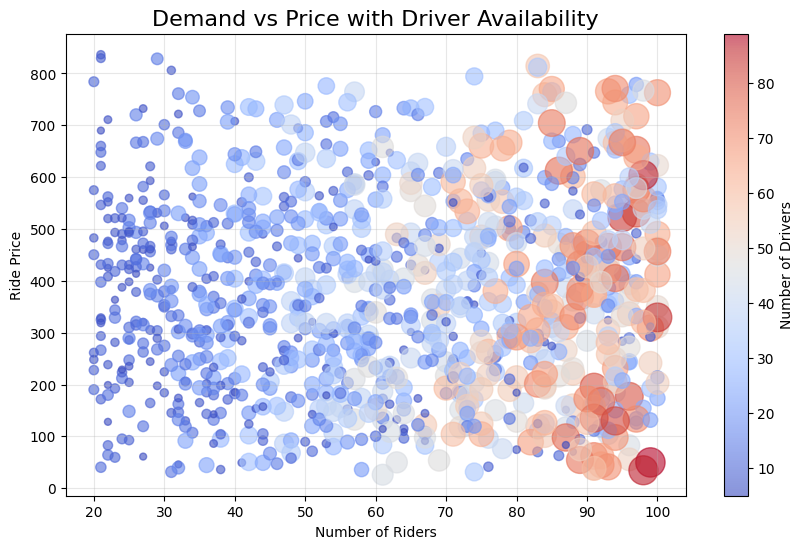

In [8]:
plt.figure(figsize=(10,6))

plt.scatter(
    df["Number_of_Riders"],
    df["Historical_Cost_of_Ride"],
    s=df["Number_of_Drivers"]*5,
    c=df["Number_of_Drivers"],
    cmap="coolwarm",
    alpha=0.6
)

plt.colorbar(label="Number of Drivers")

plt.title("Demand vs Price with Driver Availability", fontsize=16)
plt.xlabel("Number of Riders")
plt.ylabel("Ride Price")

plt.grid(alpha=0.3)

plt.show()

# **Business Insight:**

As the number of riders increases, ride prices tend to rise, indicating demand-based surge pricing used to balance supply and demand.

# **How does driver availability affect ride pricing?**

/tmp/ipykernel_3906/2260647976.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


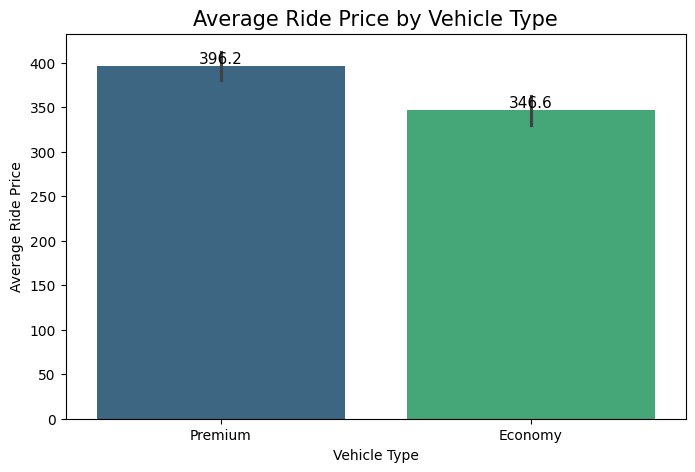

In [9]:
plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=df,
    x="Vehicle_Type",
    y="Historical_Cost_of_Ride",
    palette="viridis"
)

for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.1f}',
        (p.get_x() + p.get_width()/2., p.get_height()),
        ha='center',
        va='bottom',
        fontsize=11
    )

plt.title("Average Ride Price by Vehicle Type", fontsize=15)
plt.xlabel("Vehicle Type")
plt.ylabel("Average Ride Price")

plt.show()

# **Step 4— Feature & Target**

In [10]:
X = df.drop("Historical_Cost_of_Ride", axis=1)
y = df["Historical_Cost_of_Ride"]

# **Business Insight:**

By selecting relevant features like demand, supply, and vehicle type, the model can learn the key factors that influence ride pricing and make accurate price predictions.

# **How do we convert categorical data into numerical format for the model?**

In [11]:
categorical = ["Vehicle_Type","Location_Category"]
numeric = ["Number_of_Riders","Number_of_Drivers","Expected_Ride_Duration"]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(), categorical),
        ("num", "passthrough", numeric)
    ]
)

# **Step 5 — Model Creation**

In [12]:
model = RandomForestRegressor(n_estimators=200)

# **Business Insight:**

Used Random Forest Regression with 200 trees to capture complex patterns between ride demand factors and ride prices, improving prediction accuracy.

# **Step 6 — Build Pipeline**

In [13]:
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", model)
])

Built a machine learning pipeline to automate preprocessing and model training, ensuring consistent data transformation and improving model reliability.

# **Step 7 — Train/Test Split**

In [14]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

# **Project Insight:**

Split the dataset into 80% training and 20% testing data to ensure the model learns patterns from historical ride data while validating its performance on unseen rides.

# **Step 8 — Train Model**

In [15]:
pipeline.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat', OneHotEncoder(),
                                                  ['Vehicle_Type',
                                                   'Location_Category']),
                                                 ('num', 'passthrough',
                                                  ['Number_of_Riders',
                                                   'Number_of_Drivers',
                                                   'Expected_Ride_Duration'])])),
                ('model', RandomForestRegressor(n_estimators=200))])

# **Business Insight :**

The model was trained on historical ride data to learn patterns between demand factors (riders, drivers, distance) and ride prices.

# **Step 9 — Model Evaluation**

In [16]:
pred = pipeline.predict(X_test)

mae = mean_absolute_error(y_test,pred)

print("Model Error:",mae)

Model Error: 56.41583516309414


## **Business Insight: **

Evaluated model performance using Mean Absolute Error to measure the average difference between predicted and actual ride prices.

# **Step 12 — Save the Model**

In [17]:
joblib.dump(pipeline,"pricing_model.pkl")

['pricing_model.pkl']

# **Step 13 — Test Prediction**

In [18]:
sample = pd.DataFrame({
    "Number_of_Riders":[40],
    "Number_of_Drivers":[20],
    "Expected_Ride_Duration":[30],
    "Vehicle_Type":["Economy"],
    "Location_Category":["Urban"]
})

pipeline.predict(sample)

array([95.1639005])

In [19]:
!pip install ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 22.8 MB/s eta 0:00:00


In [20]:
import pandas as pd
import joblib
import ipywidgets as widgets
from IPython.display import display

# **Step 4 — Create GUI Inputs**

In [21]:
riders = widgets.IntSlider(
    value=20,
    min=1,
    max=100,
    description='Riders'
)

drivers = widgets.IntSlider(
    value=30,
    min=1,
    max=80,
    description='Drivers'
)

duration = widgets.IntSlider(
    value=25,
    min=5,
    max=60,
    description='Duration'
)

vehicle = widgets.Dropdown(
    options=['Economy','Premium','SUV'],
    description='Vehicle'
)

location = widgets.Dropdown(
    options=['Urban','Suburban','Rural'],
    description='Location'
)

predict_button = widgets.Button(description="Predict Price")

output = widgets.Output()

# **Step 5 — Prediction Function**

In [35]:
def predict_price(b):

    input_data = pd.DataFrame({
        "Number_of_Riders":[riders.value],
        "Number_of_Drivers":[drivers.value],
        "Expected_Ride_Duration":[duration.value],

        "Vehicle_Economy":[1 if vehicle.value=="Economy" else 0],
        "Vehicle_Premium":[1 if vehicle.value=="Premium" else 0],
        "Vehicle_SUV":[1 if vehicle.value=="SUV" else 0],

        "Location_Urban":[1 if location.value=="Urban" else 0],
        "Location_Suburban":[1 if location.value=="Suburban" else 0],
        "Location_Rural":[1 if location.value=="Rural" else 0]
    })

    price = model.predict(input_data)[0]

    with output:
        output.clear_output()
        print("Estimated Ride Price: ₹", round(price,2))

# **Connect Button**

In [33]:
predict_button.on_click(predict_price)

# **Step 7 — Display GUI**

In [36]:
display(riders, drivers, duration, vehicle, location, predict_button, output)

IntSlider(value=20, description='Riders', min=1)

IntSlider(value=30, description='Drivers', max=80, min=1)

IntSlider(value=25, description='Duration', max=60, min=5)

Dropdown(description='Vehicle', index=1, options=('Economy', 'Premium', 'SUV'), value='Premium')

Dropdown(description='Location', index=2, options=('Urban', 'Suburban', 'Rural'), value='Rural')

Button(description='Predict Price', style=ButtonStyle())

Output()

# **Key Insights:**

Some insights discovered during analysis:

• Ride prices increase when rider demand increases

• Prices decrease when more drivers are available

• Premium and SUV rides cost significantly more than economy rides

• Urban locations show higher ride prices compared to rural areas

# **Future Improvements:**

Possible enhancements:
•	Real-time surge pricing algorithm

•	demand forecasting model

•	deep learning price prediction

•	live dashboard using Streamlit

•	API deployment

